#### 1. Data import and device

In [1]:
from IPython.display import display
import os
import gc
from collections import Counter, defaultdict
from concurrent.futures import ThreadPoolExecutor
from pathlib import Path

import imagehash
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as T
from matplotlib import pyplot as plt
from PIL import Image, UnidentifiedImageError
from sklearn.metrics import classification_report, confusion_matrix, top_k_accuracy_score
from torch.utils.data import DataLoader, Dataset, random_split
from tqdm import tqdm
import torchvision.models as models

In [2]:

from pathlib import Path
import shutil
from collections import Counter
from torchvision import datasets

def filter_dataset_by_min_samples(src_dir, dst_dir, min_samples=5):
    src_dir = Path(src_dir)
    dst_dir = Path(dst_dir)

    # 用 ImageFolder 统计类别
    temp_dataset = datasets.ImageFolder(src_dir)
    targets = [label for _, label in temp_dataset.samples]
    counts = Counter(targets)

    # 清空目标目录
    if dst_dir.exists():
        shutil.rmtree(dst_dir)
    dst_dir.mkdir(parents=True, exist_ok=True)

    kept_classes = []
    removed_classes = []

    # 遍历类别
    for class_idx, class_name in enumerate(temp_dataset.classes):
        src_class_dir = src_dir / class_name

        if counts[class_idx] >= min_samples:
            dst_class_dir = dst_dir / class_name
            shutil.copytree(src_class_dir, dst_class_dir)
            kept_classes.append((class_name, counts[class_idx]))
        else:
            removed_classes.append((class_name, counts[class_idx]))

    print(f"\n Kept {len(kept_classes)} classes:")
    print(kept_classes[:10], "..." if len(kept_classes) > 10 else "")

    print(f"\n Removed {len(removed_classes)} classes:")
    print(removed_classes)

    return dst_dir


# cleaning up those has pictures less than 10
ROOT = Path(__file__).resolve().parent if '__file__' in vars() else Path(globals().get('__vsc_ipynb_file__', __import__('os').path.abspath(''))).resolve().parent
DATA_DIR_BEFORE_FILTER = ROOT /  "archive" / "DogBreedsImageDataset"
filtered_path = ROOT / "archive" / "DogBreedsImageDatasetFilter"

if not DATA_DIR_BEFORE_FILTER.exists():
    raise FileNotFoundError(f"Dataset directory not found: {DATA_DIR_BEFORE_FILTER}")

if not filtered_path.exists():
    filter_dataset_by_min_samples(DATA_DIR_BEFORE_FILTER, filtered_path, 10)

DATA_DIR = filtered_path

# --- config ---
IMG_SIZE = 224
BATCH_SIZE = 32
VAL_SPLIT = 0.2
NUM_WORKERS = 4
SEED = 2
PIN = torch.cuda.is_available()
device = torch.device("cuda" if PIN else "cpu")
torch.multiprocessing.set_sharing_strategy('file_system')

# More suitable normalization defaults for RGB image classification
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

train_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

test_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


def get_loaders(
        data_dir: str = DATA_DIR,
        batch_size: int = BATCH_SIZE,
        val_split: float = VAL_SPLIT,
        num_workers: int = NUM_WORKERS,
        pin_memory: bool = PIN,
        cleaned_samples=None,
        cleaned_targets=None,
):
    full = torchvision.datasets.ImageFolder(root=data_dir, transform=train_tf)

    if cleaned_samples is not None:
        full.samples = cleaned_samples
        full.imgs = cleaned_samples
        full.targets = cleaned_targets

    n = len(full)
    n_val = int(n * val_split)
    n_train = n - n_val

    train_set, val_set = random_split(full, [n_train, n_val])

    val_full = torchvision.datasets.ImageFolder(root=data_dir, transform=val_tf)
    if cleaned_samples is not None:
        val_full.samples = cleaned_samples
        val_full.imgs = cleaned_samples
        val_full.targets = cleaned_targets
    val_set.dataset = val_full

    class_to_idx = full.class_to_idx
    idx_to_class = {v: k for k, v in class_to_idx.items()}

    train_loader = DataLoader(
        train_set, batch_size=batch_size, shuffle=True,
        num_workers=num_workers, pin_memory=pin_memory, drop_last=False
    )
    val_loader = DataLoader(
        val_set, batch_size=batch_size * 2, shuffle=False,
        num_workers=num_workers, pin_memory=pin_memory, drop_last=False
    )
    return train_loader, val_loader, idx_to_class


train_loader, val_loader, idx_to_class = get_loaders()

xb, yb = next(iter(train_loader))

### 2. Data cleaning

In [3]:
dataset = torchvision.datasets.ImageFolder(root=DATA_DIR)
class_counts = Counter(dataset.targets)


### 3. Data Cleaning (Robust & Multi-Threaded English Version)
# ─────────────────────────────────────────────────────────────────────
# Step 1: Corrupted & Tiny Image Detection
# ─────────────────────────────────────────────────────────────────────
def verify_image(file_path: Path) -> Path | None:
    """Checks if an image is corrupted or too small to be useful."""
    try:
        with Image.open(file_path) as img:
            img.verify()

        with Image.open(file_path) as img:
            if img.size[0] < 10 or img.size[1] < 10:
                return file_path
        return None
    except (IOError, SyntaxError, UnidentifiedImageError, Exception):
        return file_path

print("=" * 60)
print("Phase 1: Scanning for Corrupted or Invalid Images...")
print("=" * 60)

# Gather all image paths
image_extensions = {'.jpg', '.jpeg', '.png', '.webp', '.bmp', '.tif', '.tiff'}
all_images = [p for p in Path(DATA_DIR).rglob('*') if p.suffix.lower() in image_extensions]
original_count = len(all_images)
print(f"Total images found: {original_count}\n")

# Parallel Verification
with ThreadPoolExecutor(max_workers=NUM_WORKERS * 2) as executor:
    results = list(tqdm(executor.map(verify_image, all_images),
                        total=len(all_images), desc="Verifying Integrity"))

corrupted_files = [res for res in results if res is not None]
# Filter out corrupted files for the next step
valid_images_list = [p for p in all_images if p not in set(corrupted_files)]

# ─────────────────────────────────────────────────────────────────────
# Step 2: Perceptual Hashing — Duplicates & Label Conflicts
# ─────────────────────────────────────────────────────────────────────
def compute_phash(file_path: Path) -> tuple[Path, str | None]:
    """Computes the Perceptual Hash (pHash) of an image."""
    try:
        with Image.open(file_path) as img:
            return file_path, str(imagehash.phash(img))
    except Exception:
        return file_path, None

print("\n" + "=" * 60)
print("Phase 2: Running pHash — Detecting Duplicates & Label Conflicts...")
print("=" * 60)

with ThreadPoolExecutor(max_workers=NUM_WORKERS * 2) as executor:
    hash_results = list(tqdm(executor.map(compute_phash, valid_images_list),
                             total=len(valid_images_list), desc="Computing Hashes"))

# Map hashes to paths and labels: {hash: [(path, label), ...]}
hash_map = defaultdict(list)
for file_path, h in hash_results:
    if h is not None:
        label = file_path.parent.name
        hash_map[h].append((file_path, label))

# Analyze duplicates and conflicts
duplicates_to_remove = set()  # Same image, same label
conflict_files = set()       # Same image, DIFFERENT labels

for h, entries in hash_map.items():
    if len(entries) > 1:
        unique_labels = {label for _, label in entries}

        if len(unique_labels) > 1:
            # MEDICAL SAFETY STRATEGY:
            # If an image has conflicting labels, discard the entire group.
            for p, _ in entries:
                conflict_files.add(p)
        else:
            # Simple Duplicates: Keep the first one, flag the rest for removal.
            for p, _ in entries[1:]:
                duplicates_to_remove.add(p)

# ─────────────────────────────────────────────────────────────────────
# Step 3: Summary Report & Physical Cleanup
# ─────────────────────────────────────────────────────────────────────
files_to_remove = set(corrupted_files) | duplicates_to_remove | conflict_files

# Print conflict examples for debugging
if conflict_files:
    print(f"\nAlert: Label Conflicts Detected! Identical images found in multiple categories:")
    conflict_count = 0
    for h, entries in hash_map.items():
        labels = {label for _, label in entries}
        if len(labels) > 1:
            print(f"   Hash [{h}] → Shared by labels: {labels}")
            conflict_count += 1
            if conflict_count >= 3: break

bad_files_set = {str(p.resolve()) for p in files_to_remove}

valid_samples = []
valid_targets = []

for path, target in dataset.samples:
    if str(Path(path).resolve()) not in bad_files_set:
        valid_samples.append((path, target))
        valid_targets.append(target)

dataset.samples = valid_samples
# imgs: former name of samples;
# Compatibility with legacy code
# Same as the samples (content)
dataset.imgs = valid_samples
dataset.targets = valid_targets

final_count = len(dataset.samples)

print("\n" + "=" * 60)
print("                  DATA CLEANING SUMMARY")
print("=" * 60)
print(f"  {'Initial Image Count:':<35} {original_count:>6}")
print(f"  {'Corrupted / Invalid (Deleted):':<35} {len(corrupted_files):>6}")
print(f"  {'Duplicate Images (Deleted):':<35} {len(duplicates_to_remove):>6}")
print(f"  {'Label Conflicts (Entirely Removed):':<35} {len(conflict_files):>6}")
print("-" * 60)
print(f"  {'Total Images Removed:':<35} {len(files_to_remove):>6}")
print(f"  {'Final Cleaned Dataset Size:':<35} {final_count:>6}")
print(f"  {'Data Retention Rate:':<35} {(final_count/original_count)*100:>5.2f}%")
print("=" * 60)

# ─────────────────────────────────────────────────────────────────────
# Step 4: Rebuild train/val loaders from the cleaned dataset
# ─────────────────────────────────────────────────────────────────────
# The original loaders were built before cleaning and reference a separate
# dataset object. We recreate them here so training uses only clean samples.
train_loader, val_loader, idx_to_class = get_loaders(
    cleaned_samples=dataset.samples,
    cleaned_targets=dataset.targets,
)
print(f"Train samples : {len(train_loader.dataset)}")
print(f"Val samples   : {len(val_loader.dataset)}")

Phase 1: Scanning for Corrupted or Invalid Images...
Total images found: 12487



Verifying Integrity: 100%|██████████| 12487/12487 [00:02<00:00, 4372.15it/s]



Phase 2: Running pHash — Detecting Duplicates & Label Conflicts...


Computing Hashes: 100%|██████████| 12487/12487 [00:08<00:00, 1503.96it/s]



Alert: Label Conflicts Detected! Identical images found in multiple categories:
   Hash [e1dcd6a3c8cc7924] → Shared by labels: {'redbone', 'blood_hound'}
   Hash [831c4fe75891bea2] → Shared by labels: {'whippet', 'briard'}
   Hash [9c7040afc39fc64d] → Shared by labels: {'dingo', 'dhole'}

                  DATA CLEANING SUMMARY
  Initial Image Count:                 12487
  Corrupted / Invalid (Deleted):           0
  Duplicate Images (Deleted):             45
  Label Conflicts (Entirely Removed):     22
------------------------------------------------------------
  Total Images Removed:                   67
  Final Cleaned Dataset Size:          12420
  Data Retention Rate:                99.46%
Train samples : 9936
Val samples   : 2484


#### 3.Data visualization

show image amount, show class amount,and batch size

In [4]:
# ===== Dataset Overview =====



class_table = pd.DataFrame(
    {
        "Class Index": list(range(len(dataset.classes))),
        "Class Name": dataset.classes,
        "Image Count": [class_counts[i] for i in range(len(dataset.classes))],
    }
)

overview = pd.DataFrame(
    {
        "Metric": [
            "Total number of images",
            "Number of classes",
            "Training samples",
            "Validation samples",
            "Train batch size",
            "Validation batch size",
            "Image size",
        ],
        "Value": [
            len(dataset),
            len(dataset.classes),
            len(train_loader.dataset),
            len(val_loader.dataset),
            train_loader.batch_size,
            val_loader.batch_size,
            f"{IMG_SIZE}x{IMG_SIZE}",
        ],
    }
)

display(overview.style.hide(axis="index"))

zero_classes = class_table[class_table["Image Count"] == 0]
train_counts = Counter()

for _, labels in train_loader:
    train_counts.update(labels.tolist())

# check zero classes in train set

missing = [i for i in range(len(dataset.classes)) if train_counts.get(i, 0) == 0]
if len(missing) > 0:
    missing_labels = [(i, dataset.classes[i]) for i in missing]
    print(missing_labels)
    print("Classes missing in TRAIN:", missing)
else:
    print("No Classes missing in TRAIN:")

Metric,Value
Total number of images,12420
Number of classes,88
Training samples,9936
Validation samples,2484
Train batch size,32
Validation batch size,64
Image size,224x224


No Classes missing in TRAIN:


Display the first 3 images from the dataset.

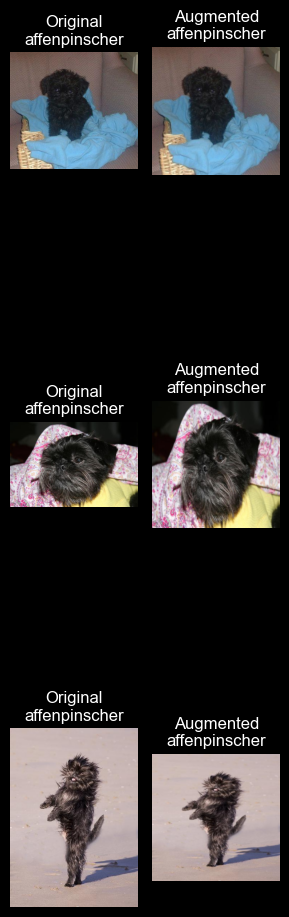

In [5]:
# Compare original images with augmented images from train_tf

def denormalize_image(image_tensor, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    mean_tensor = torch.tensor(mean).view(3, 1, 1)
    std_tensor = torch.tensor(std).view(3, 1, 1)
    image_tensor = image_tensor.detach().cpu() * std_tensor + mean_tensor
    return image_tensor.clamp(0, 1).permute(1, 2, 0).numpy()

num_compare = 3
fig, axes = plt.subplots(num_compare, 2, figsize=(3, 4 * num_compare))

for i in range(num_compare):
    original_img, label = dataset[i]
    augmented_img = train_tf(original_img)

    axes[i, 0].imshow(original_img)
    axes[i, 0].set_title(f"Original\n{dataset.classes[label]}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(denormalize_image(augmented_img))
    axes[i, 1].set_title(f"Augmented\n{dataset.classes[label]}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

Count images per class to check class balance.

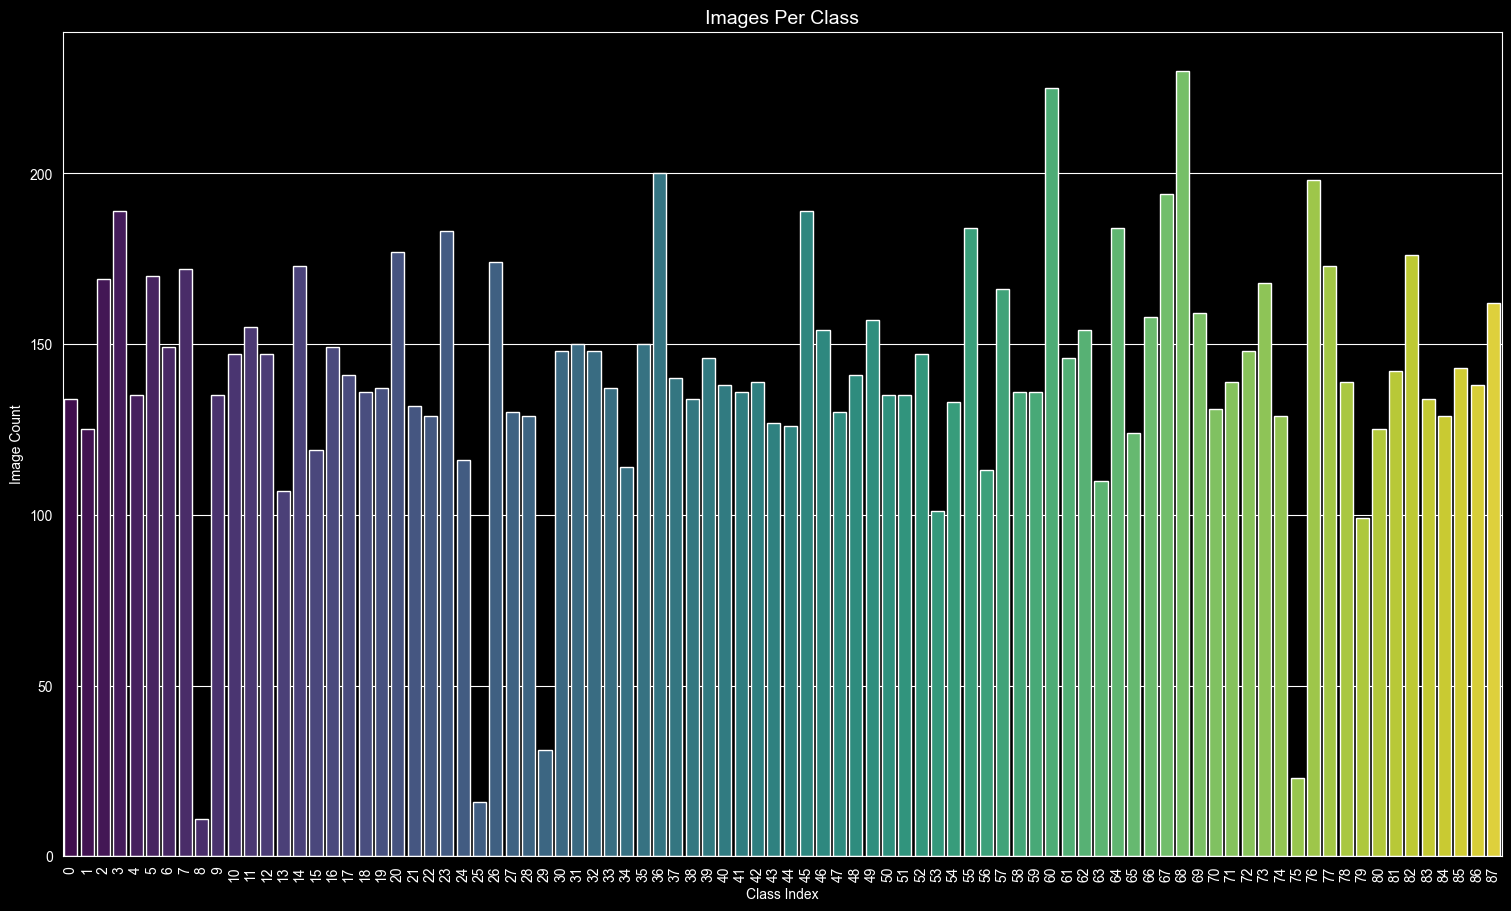

In [6]:
plot_data = class_table.assign(
    **{"Class Index": class_table["Class Index"].astype(str)}
)

fig, ax_bar = plt.subplots(
    figsize=(15, 9),
    constrained_layout=True,
)

sns.barplot(
    data=plot_data,
    x="Class Index",
    y="Image Count",
    hue="Class Index",
    dodge=False,
    palette="viridis",
    legend=False,
    ax=ax_bar,
)

ax_bar.set_title("Images Per Class", fontsize=14)
ax_bar.set_xlabel("Class Index")
ax_bar.set_ylabel("Image Count")
ax_bar.tick_params(axis="x", rotation=90)

plt.show()

#### 4. Model and comparison model

ResNet50

In [7]:
def build_resnet50_classifier(num_classes=157):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

EfficientNet-B0

In [8]:
def build_efficientnet_classifier(num_classes=157):
    model = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

#### 5. Model training

In [9]:

# The entire training dataset was used to train the model for 50 epochs.
EPOCHS = 50
LEARNING_RATE = 3e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 4

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

gc.collect()

def get_loader_targets(loader):
    data = loader.dataset
    if hasattr(data, 'targets'):
        return list(data.targets)
    if hasattr(data, 'indices') and hasattr(data.dataset, 'targets'):
        return [data.dataset.targets[i] for i in data.indices]
    raise ValueError('Unable to read targets from the provided loader.')

def get_loader_classes(loader):
    """Get classes from a loader whose dataset may be a Subset."""
    ds = loader.dataset
    if hasattr(ds, 'classes'):
        return ds.classes
    if hasattr(ds, 'dataset') and hasattr(ds.dataset, 'classes'):
        return ds.dataset.classes
    raise ValueError('Unable to read classes from the provided loader.')

def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

def validate(model, loader, criterion, device):
    """Validate the model."""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    epoch_loss = running_loss / total
    epoch_acc = 100.0 * correct / total
    return epoch_loss, epoch_acc

def train_model(model, train_loader, val_loader, epochs=EPOCHS, lr=LEARNING_RATE,
                weight_decay=WEIGHT_DECAY, patience=PATIENCE, model_name="model"):
    """Complete training loop with early stopping and checkpointing."""
    model = model.to(device)
    targets = get_loader_targets(train_loader)

    counts = Counter(targets)
    num_classes = len(get_loader_classes(train_loader))
    total_samples = sum(counts.values())

    class_weights = torch.tensor(
        [total_samples / counts[i] for i in range(num_classes)],
        dtype=torch.float,
        device=device,
    )
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.05)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=2
    )

    best_val_acc = 0.0
    best_epoch = 0
    epochs_no_improve = 0
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

    print(f"\nStarting training for {model_name}...")
    print("-" * 70)

    for epoch in range(epochs):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = validate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        scheduler.step(val_loss)

        print(
            f"Epoch {epoch + 1:2d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} Acc: {train_acc:6.2f}% | "
            f"Val Loss: {val_loss:.4f} Acc: {val_acc:6.2f}%",
            end="",
            flush=True,
        )

        # Early stopping & checkpoint
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            epochs_no_improve = 0
            torch.save({'model_state_dict': model.state_dict(),'history': history}, f'best_{model_name}.pth')
            print(f" ✓ [Best: {val_acc:.2f}%]")
        else:
            epochs_no_improve += 1
            print(flush=True)

        if epochs_no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch + 1}")
            print(f"Best validation accuracy: {best_val_acc:.2f}% (epoch {best_epoch})")
            break

    model_checkpoint = torch.load(f'best_{model_name}.pth', map_location=device)
    model.load_state_dict(model_checkpoint['model_state_dict'])
    print(f"\nTraining complete. Best model saved as 'best_{model_name}.pth'")
    print("-" * 70)
    return model, history

# Train ResNet50
print("=" * 70)
print("RESNET50")
print("=" * 70)

resnet_model = build_resnet50_classifier(num_classes=len(idx_to_class))

resnet_path = "best_resnet50.pth"

if os.path.exists(resnet_path):
    print(f" Found existing model: {resnet_path}, loading...")
    checkpoint = torch.load(resnet_path, map_location=device)
    resnet_model.load_state_dict(checkpoint['model_state_dict'])
    resnet_model = resnet_model.to(device)
    resnet_model.eval()
    resnet_history = checkpoint.get('history', None)
else:
    print(" No saved model found, start training...")
    resnet_model, resnet_history = train_model(
        resnet_model, train_loader, val_loader,
        model_name="resnet50"
    )

# Train EfficientNetB0
print("\n" + "=" * 70)
print("EFFICIENTNET B0")
print("=" * 70)

efficientnet_model = build_efficientnet_classifier(num_classes=len(idx_to_class))

efficientnet_path = "best_efficientnet_b0.pth"

if os.path.exists(efficientnet_path):
    print(f" Found existing model: {efficientnet_path}, loading...")
    checkpoint = torch.load(efficientnet_path, map_location=device)
    efficientnet_model.load_state_dict(checkpoint['model_state_dict'])
    efficientnet_model = efficientnet_model.to(device)
    efficientnet_model.eval()
    efficientnet_history = checkpoint.get('history', None)
else:
    print(" No saved model found, start training...")
    efficientnet_model, efficientnet_history = train_model(
        efficientnet_model, train_loader, val_loader,
        model_name="efficientnet_b0"
    )



RESNET50
 Found existing model: best_resnet50.pth, loading...

EFFICIENTNET B0
 Found existing model: best_efficientnet_b0.pth, loading...


#### 6. Model performance comparison

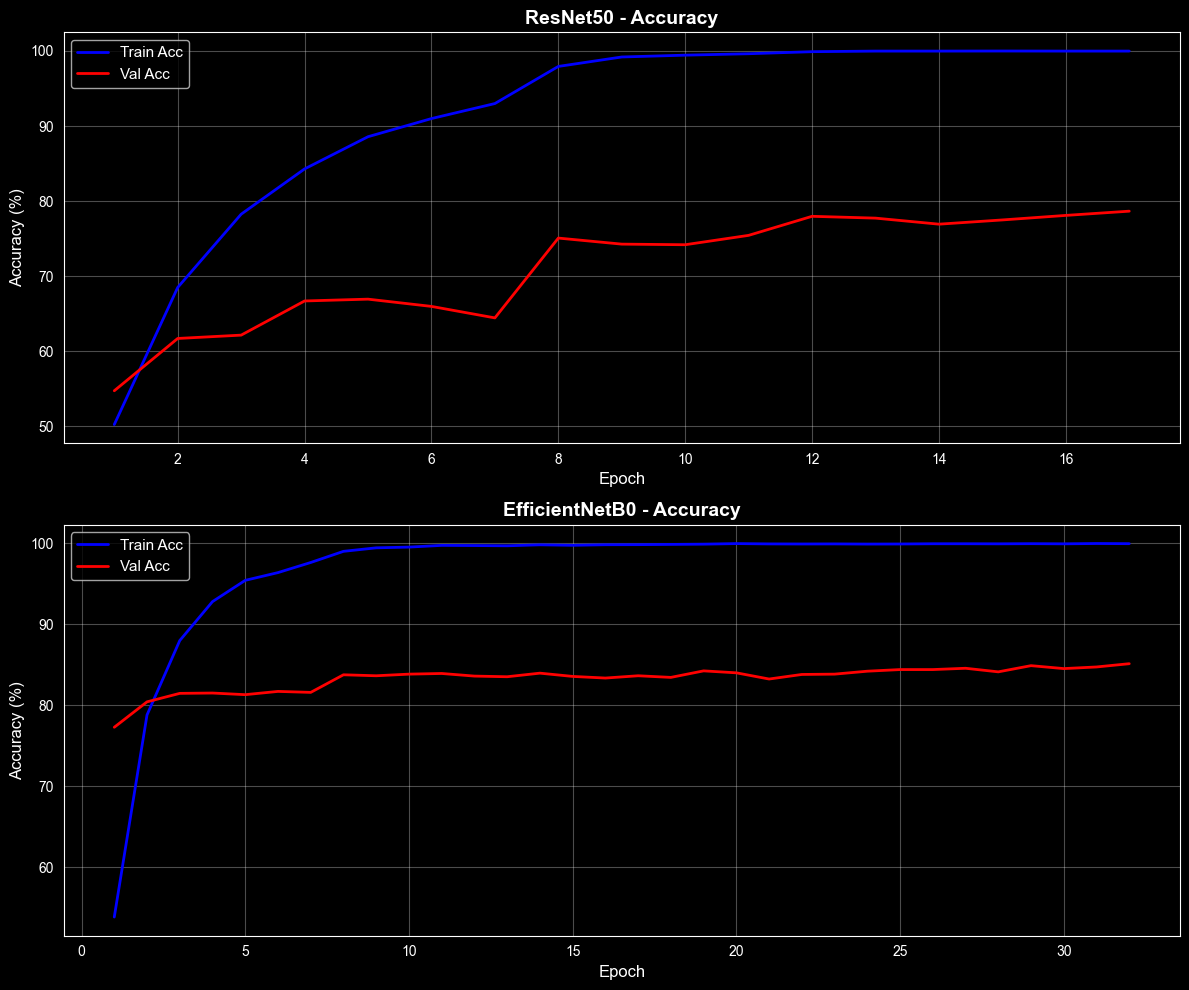

In [10]:
def plot_training_histories(history1, history2, model_name1, model_name2):
    """Plot training and validation accuracy for two models."""
    fig, axes = plt.subplots(2, 1, figsize=(12, 10), sharex=False)

    epochs1 = range(1, len(history1['train_acc']) + 1)
    axes[0].plot(epochs1, history1['train_acc'], 'b-', label='Train Acc', linewidth=2)
    axes[0].plot(epochs1, history1['val_acc'], 'r-', label='Val Acc', linewidth=2)
    axes[0].set_title(f'{model_name1} - Accuracy', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('Accuracy (%)', fontsize=12)
    axes[0].set_xlabel('Epoch', fontsize=12)
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    epochs2 = range(1, len(history2['train_acc']) + 1)
    axes[1].plot(epochs2, history2['train_acc'], 'b-', label='Train Acc', linewidth=2)
    axes[1].plot(epochs2, history2['val_acc'], 'r-', label='Val Acc', linewidth=2)
    axes[1].set_title(f'{model_name2} - Accuracy', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('Accuracy (%)', fontsize=12)
    axes[1].set_xlabel('Epoch', fontsize=12)
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Plot comparison of both models
plot_training_histories(resnet_history, efficientnet_history, 'ResNet50', 'EfficientNetB0')

In [11]:
def evaluate_model_pytorch(model, loader, device, k=3):
    """Evaluate PyTorch model and return metrics"""
    model.eval()
    all_preds = []
    all_probs = []
    all_labels = []
    total_loss = 0.0
    correct = 0
    total = 0

    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    avg_loss = total_loss / total
    accuracy = 100. * correct / total

    # Calculate top-k accuracy
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels)
    top_k_acc = top_k_accuracy_score(all_labels, all_probs, k=k) * 100

    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'top_k_accuracy': top_k_acc,
        'predictions': np.array(all_preds),
        'probabilities': all_probs,
        'labels': all_labels
    }


print("Evaluating ResNet50...")
resnet_results = evaluate_model_pytorch(resnet_model, val_loader, device, k=3)

print("Evaluating EfficientNetB0...")
efficientnet_results = evaluate_model_pytorch(efficientnet_model, val_loader, device, k=3)

# Create comparison table
results_df = pd.DataFrame({
    'Model': ['ResNet50', 'EfficientNetB0'],
    'Validation Loss': [resnet_results['loss'], efficientnet_results['loss']],
    'Validation Accuracy (%)': [resnet_results['accuracy'], efficientnet_results['accuracy']],
    'Top-3 Accuracy (%)': [resnet_results['top_k_accuracy'], efficientnet_results['top_k_accuracy']]
})

print("\n" + "=" * 70)
print("=" * 70)
display(results_df.style.format({
    'Validation Loss': '{:.4f}',
    'Validation Accuracy (%)': '{:.2f}',
    'Top-3 Accuracy (%)': '{:.2f}'
}).hide(axis="index"))

Evaluating ResNet50...
Evaluating EfficientNetB0...



Model,Validation Loss,Validation Accuracy (%),Top-3 Accuracy (%)
ResNet50,0.2170,96.10,98.55
EfficientNetB0,0.1598,97.18,99.19



CLASSIFICATION REPORT
ResNet50
                 precision    recall  f1-score   support

  affenpinscher      0.917     1.000     0.957        22
   afghan_hound      1.000     1.000     1.000        21
        african      0.976     0.976     0.976        41
       airedale      0.919     1.000     0.958        34
    appenzeller      0.967     0.967     0.967        30
        basenji      0.943     0.971     0.957        34
   basset_hound      0.958     0.920     0.939        25
         beagle      0.917     0.957     0.936        46
   bichon_frise      1.000     1.000     1.000         4
    blood_hound      1.000     0.969     0.984        32
       bluetick      0.963     0.963     0.963        27
  border_collie      0.967     1.000     0.983        29
 border_terrier      1.000     0.968     0.984        31
         borzoi      1.000     0.950     0.974        20
 boston_bulldog      0.971     0.971     0.971        34
        bouvier      1.000     1.000     1.000        2

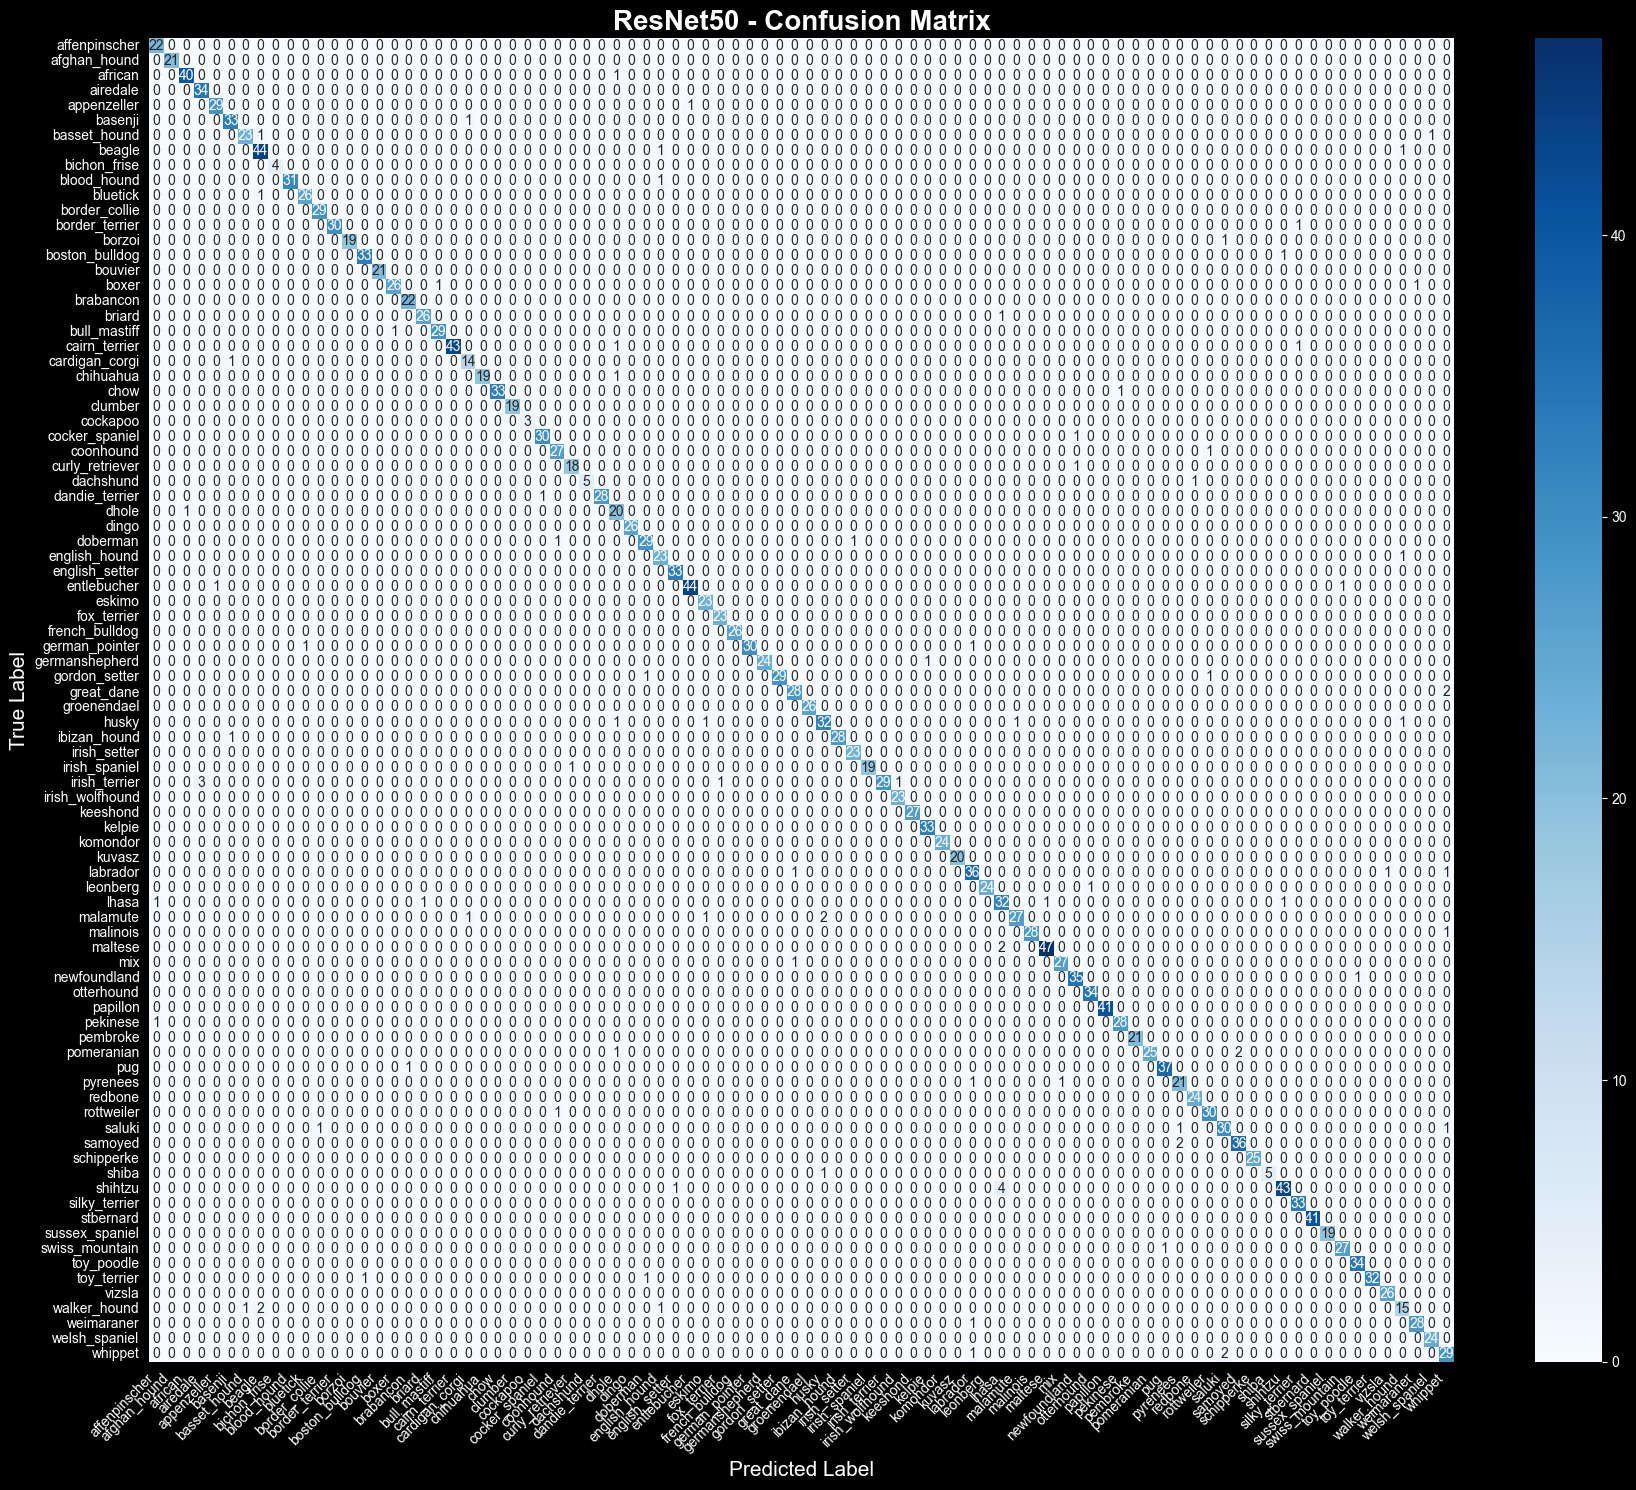

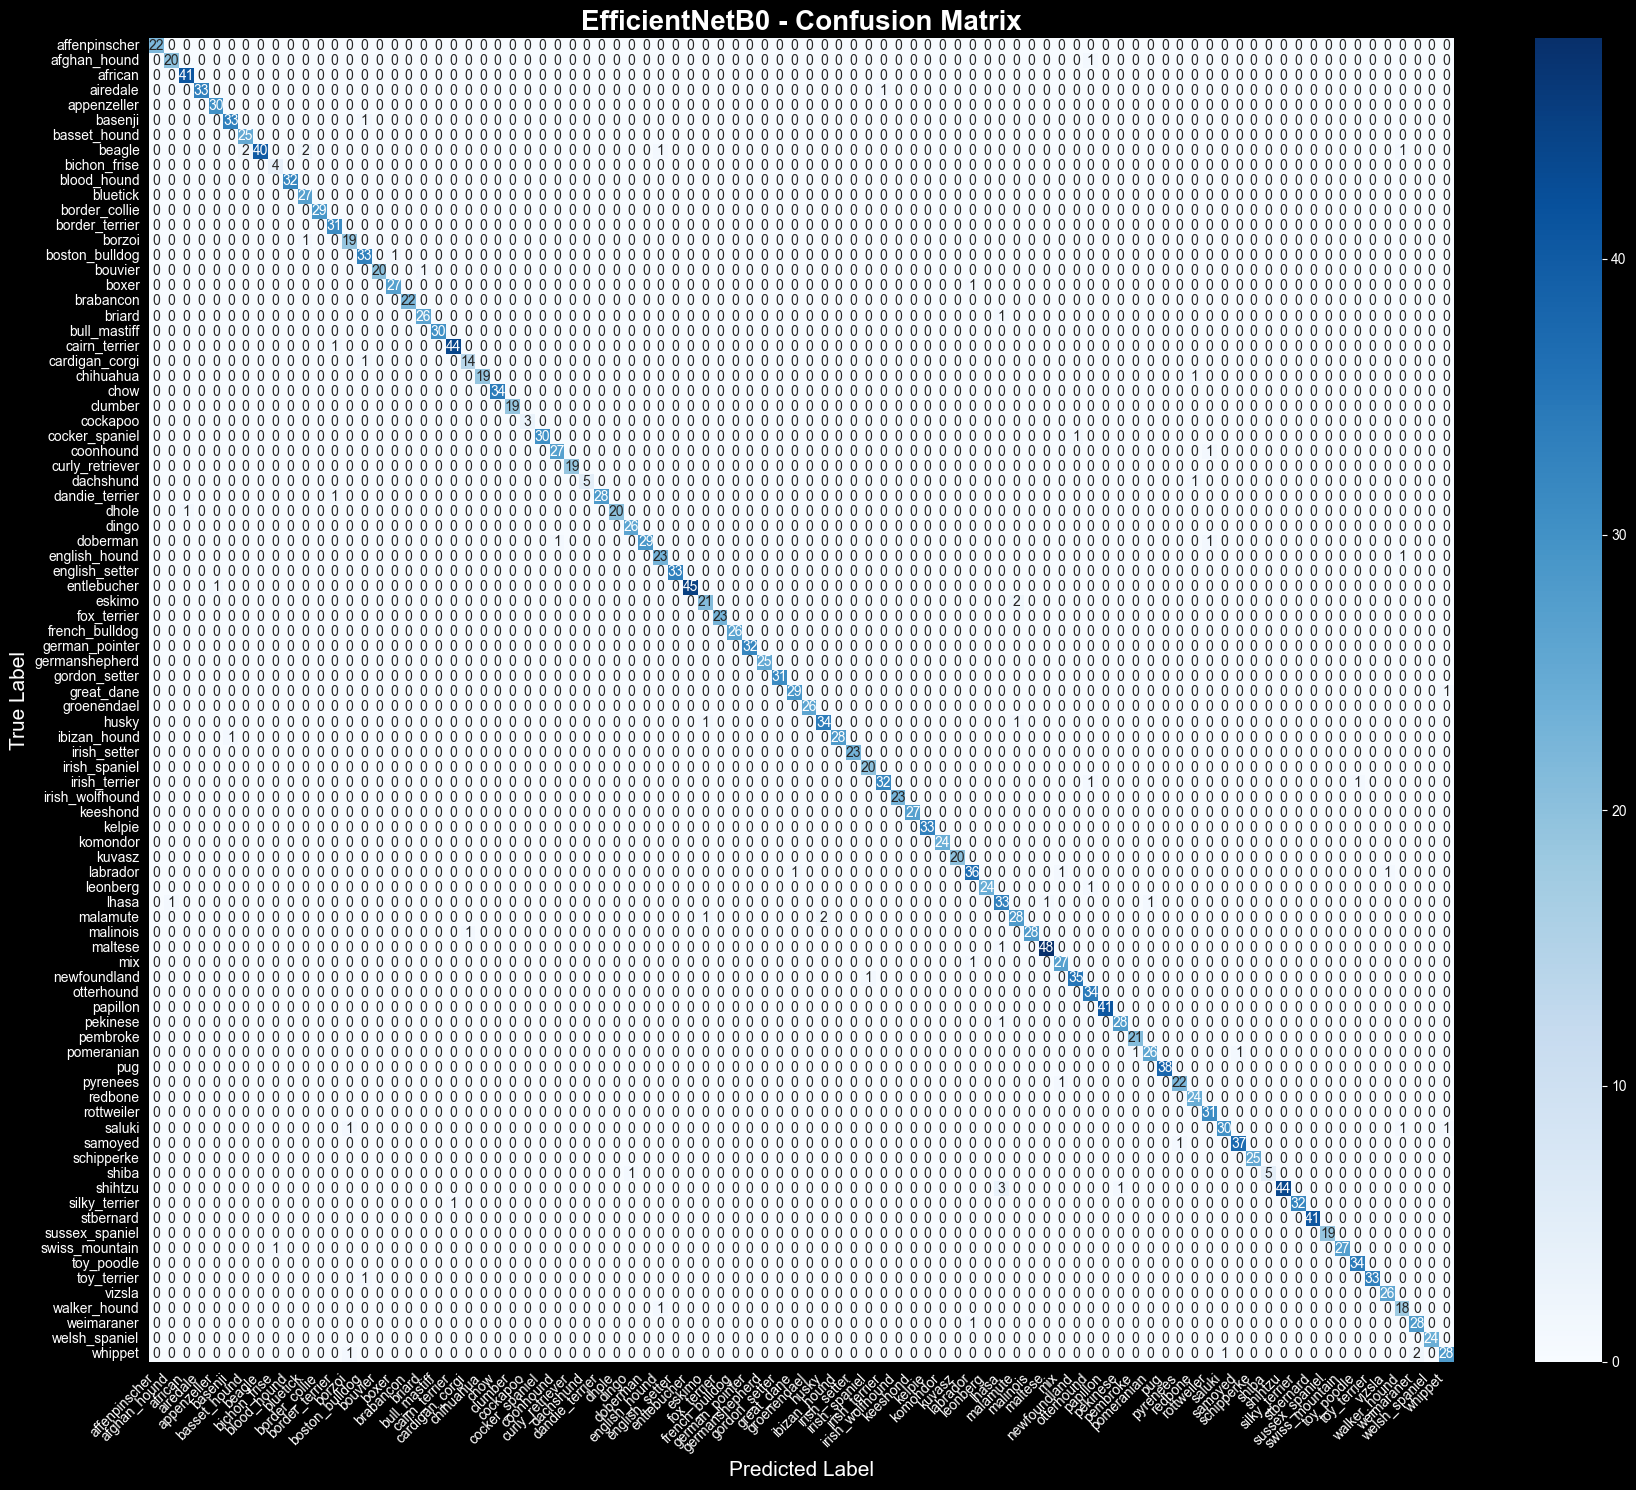

In [12]:
def get_class_names_from_loader(loader):
    """Resolve class names even when the loader dataset is a Subset."""
    ds = loader.dataset
    if hasattr(ds, 'classes'):
        return list(ds.classes)
    if hasattr(ds, 'dataset') and hasattr(ds.dataset, 'classes'):
        return list(ds.dataset.classes)
    raise ValueError('Unable to resolve class names from the provided loader.')

class_names = get_class_names_from_loader(val_loader)
print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)
print("ResNet50")
print(classification_report(
    resnet_results['labels'],
    resnet_results['predictions'],
    target_names=class_names,
    digits=3,
))
print("\nEfficientNetB0")
print(classification_report(
    efficientnet_results['labels'],
    efficientnet_results['predictions'],
    target_names=class_names,
    digits=3,
))

def plot_confusion_matrix(y_true, y_pred, model_name, class_names):
    """Plot confusion matrix heatmap"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(18, 15))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'{model_name} - Confusion Matrix', fontsize=20, fontweight='bold')
    plt.ylabel('True Label', fontsize=15)
    plt.xlabel('Predicted Label', fontsize=15)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(resnet_results['labels'], resnet_results['predictions'],
                     'ResNet50', class_names)

plot_confusion_matrix(efficientnet_results['labels'], efficientnet_results['predictions'],
                     'EfficientNetB0', class_names)

#### 7. noise VS clean performance comparison

#### add Noise: Gaussian and Salt-and-Pepper Noise

In [13]:
# Add Gaussian noise to a normalized image tensor
def add_gaussian_noise(image, mean=0.0, std=0.2):
    noise = torch.randn_like(image) * std + mean
    noisy_image = image + noise
    noisy_image = torch.clamp(noisy_image, -1.0, 1.0)
    return noisy_image

# Add Salt-and-Pepper noise to a normalized image tensor
def add_salt_and_pepper_noise(image, prob=0.02):
    noisy_image = image.clone()
    rand_tensor = torch.rand_like(image)
    # Salt (white)
    noisy_image[rand_tensor < prob / 2] = 1.0
    # Pepper (black)
    noisy_image[rand_tensor > 1 - prob / 2] = -1.0
    return noisy_image



#### add augmentation

In [14]:
from torch.utils.data import Dataset, DataLoader

#Noisy Dataset Wrapper

class NoisyDataset(Dataset):
    """Wrap a dataset and add noise to every image on the fly."""

    def __init__(self, base_dataset, noise_fn):
        self.base_dataset = base_dataset
        self.noise_fn = noise_fn

        # Copy class-related attributes so helper functions can find them
        if hasattr(base_dataset, 'classes'):
            self.classes = base_dataset.classes
        elif hasattr(base_dataset, 'dataset') and hasattr(base_dataset.dataset, 'classes'):
            self.classes = base_dataset.dataset.classes
            self.dataset = base_dataset.dataset  # for get_class_names_from_loader

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        image, label = self.base_dataset[idx]
        return self.noise_fn(image), label


#Build noisy validation loaders

# Gaussian noise loader
gaussian_val_dataset = NoisyDataset(val_loader.dataset, add_gaussian_noise)
gaussian_val_loader = DataLoader(
    gaussian_val_dataset,
    batch_size=BATCH_SIZE * 2,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

# Salt-and-Pepper noise loader
sp_val_dataset = NoisyDataset(val_loader.dataset, add_salt_and_pepper_noise)
sp_val_loader = DataLoader(
    sp_val_dataset,
    batch_size=BATCH_SIZE * 2,
    shuffle=False,
    num_workers=0,
    pin_memory=False,
)

print(f"Gaussian noisy val samples : {len(gaussian_val_dataset)}")
print(f"Salt & Pepper noisy val samples : {len(sp_val_dataset)}")


Gaussian noisy val samples : 2484
Salt & Pepper noisy val samples : 2484


#### Check result

EVALUATION ON GAUSSIAN NOISY VALIDATION SET
Evaluating ResNet50 on Gaussian noise...
Evaluating EfficientNetB0 on Gaussian noise...

EVALUATION ON SALT & PEPPER NOISY VALIDATION SET
Evaluating ResNet50 on Salt & Pepper noise...
Evaluating EfficientNetB0 on Salt & Pepper noise...

CLEAN vs NOISY PERFORMANCE COMPARISON


Model,Validation Loss,Accuracy (%),Top-3 Accuracy (%)
ResNet50 (Clean),0.2170,96.10,98.55
EfficientNetB0 (Clean),0.1598,97.18,99.19
ResNet50 (Gaussian),2.0099,56.76,75.04
EfficientNetB0 (Gaussian),1.7163,59.22,77.82
ResNet50 (S&P),0.8313,82.69,92.55
EfficientNetB0 (S&P),0.2307,95.93,98.55



CLASSIFICATION REPORT — Gaussian Noise
ResNet50 (Gaussian)
                 precision    recall  f1-score   support

  affenpinscher      0.667     0.182     0.286        22
   afghan_hound      1.000     0.286     0.444        21
        african      0.396     0.878     0.545        41
       airedale      0.230     0.941     0.370        34
    appenzeller      0.543     0.633     0.585        30
        basenji      0.337     0.853     0.483        34
   basset_hound      0.889     0.640     0.744        25
         beagle      0.552     0.696     0.615        46
   bichon_frise      0.000     0.000     0.000         4
    blood_hound      1.000     0.531     0.694        32
       bluetick      0.714     0.741     0.727        27
  border_collie      0.800     0.138     0.235        29
 border_terrier      0.824     0.452     0.583        31
         borzoi      0.706     0.600     0.649        20
 boston_bulldog      0.818     0.529     0.643        34
        bouvier      0.349 

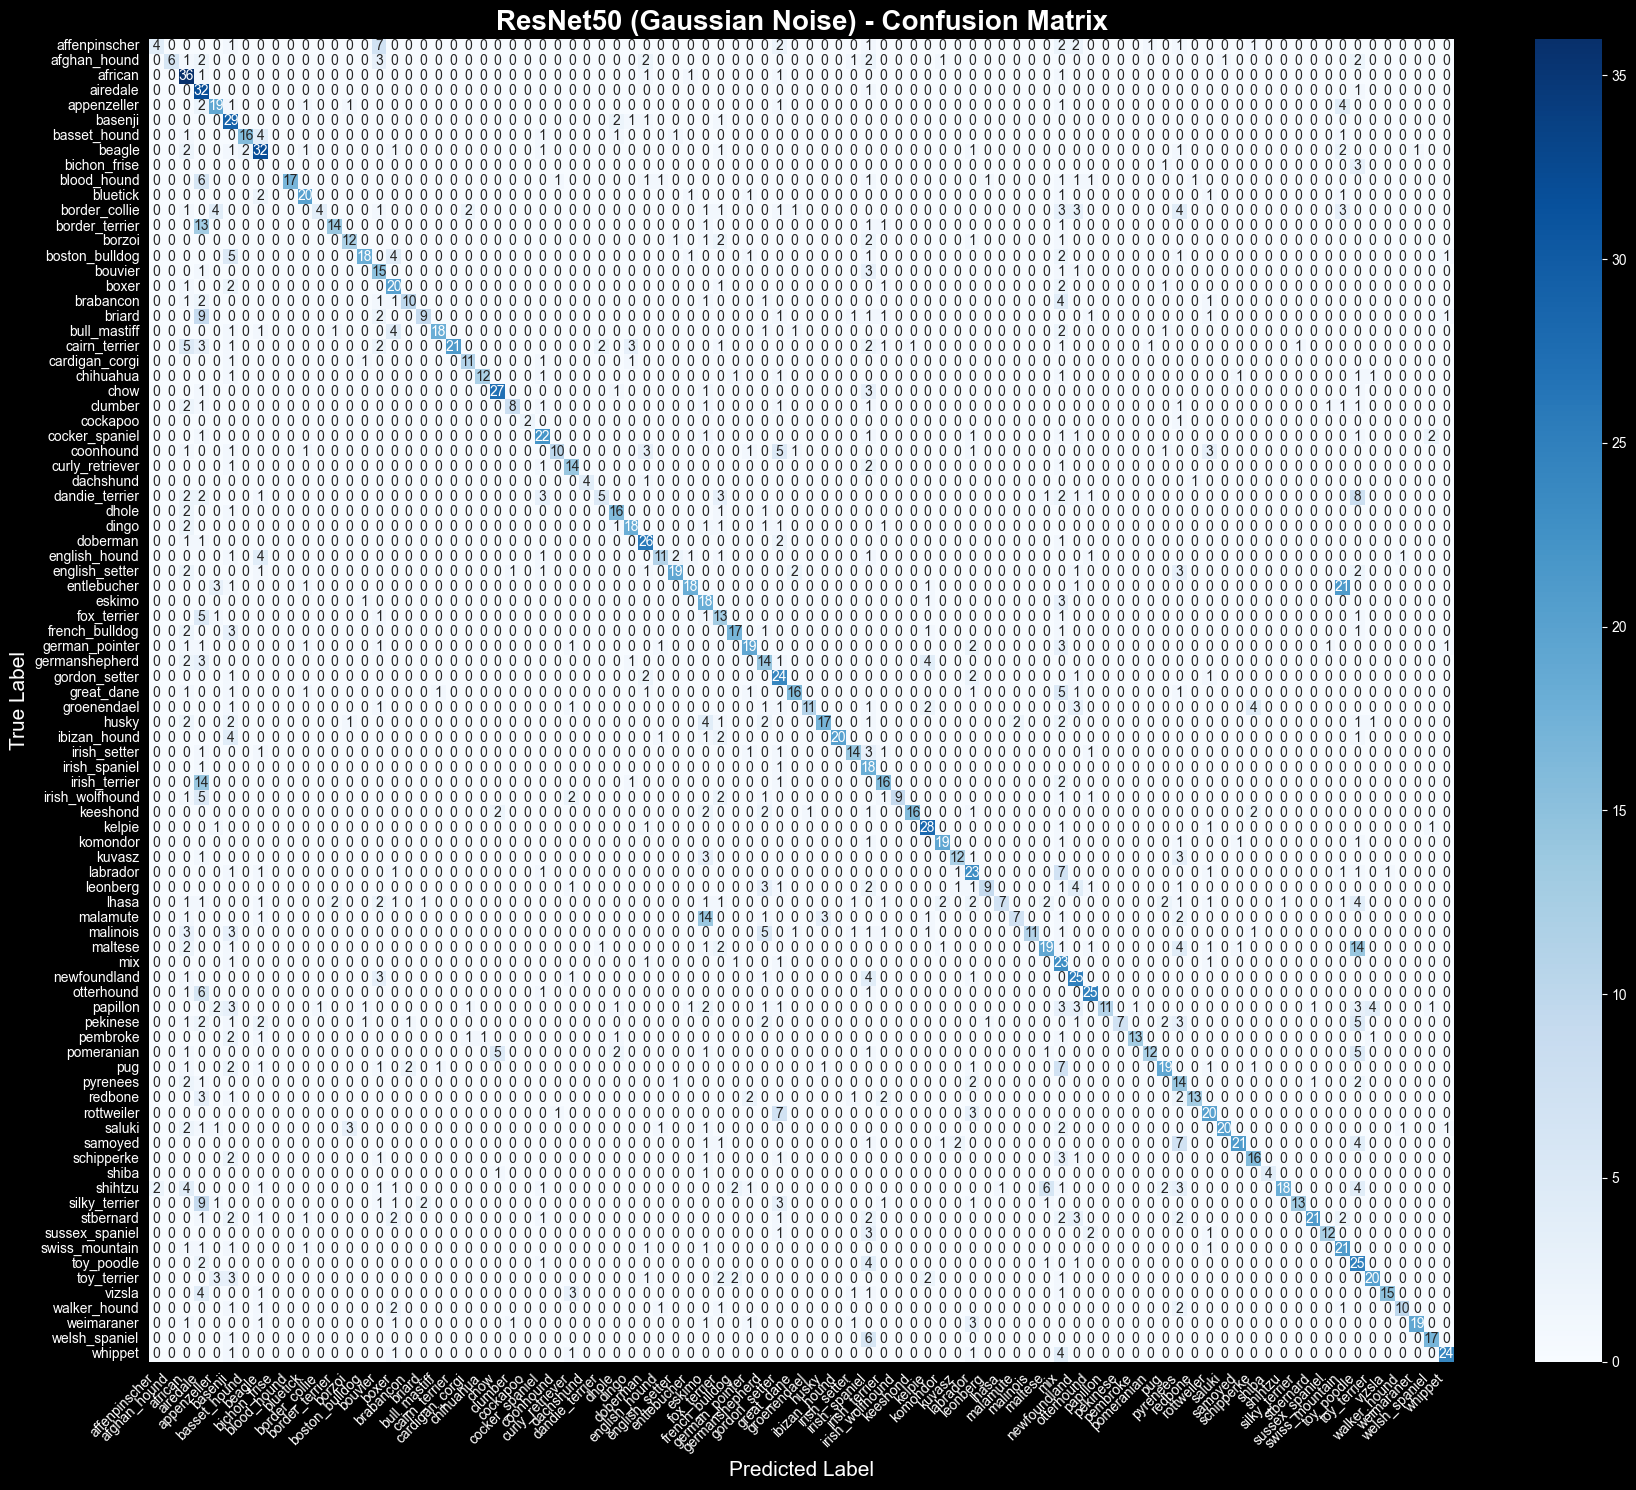

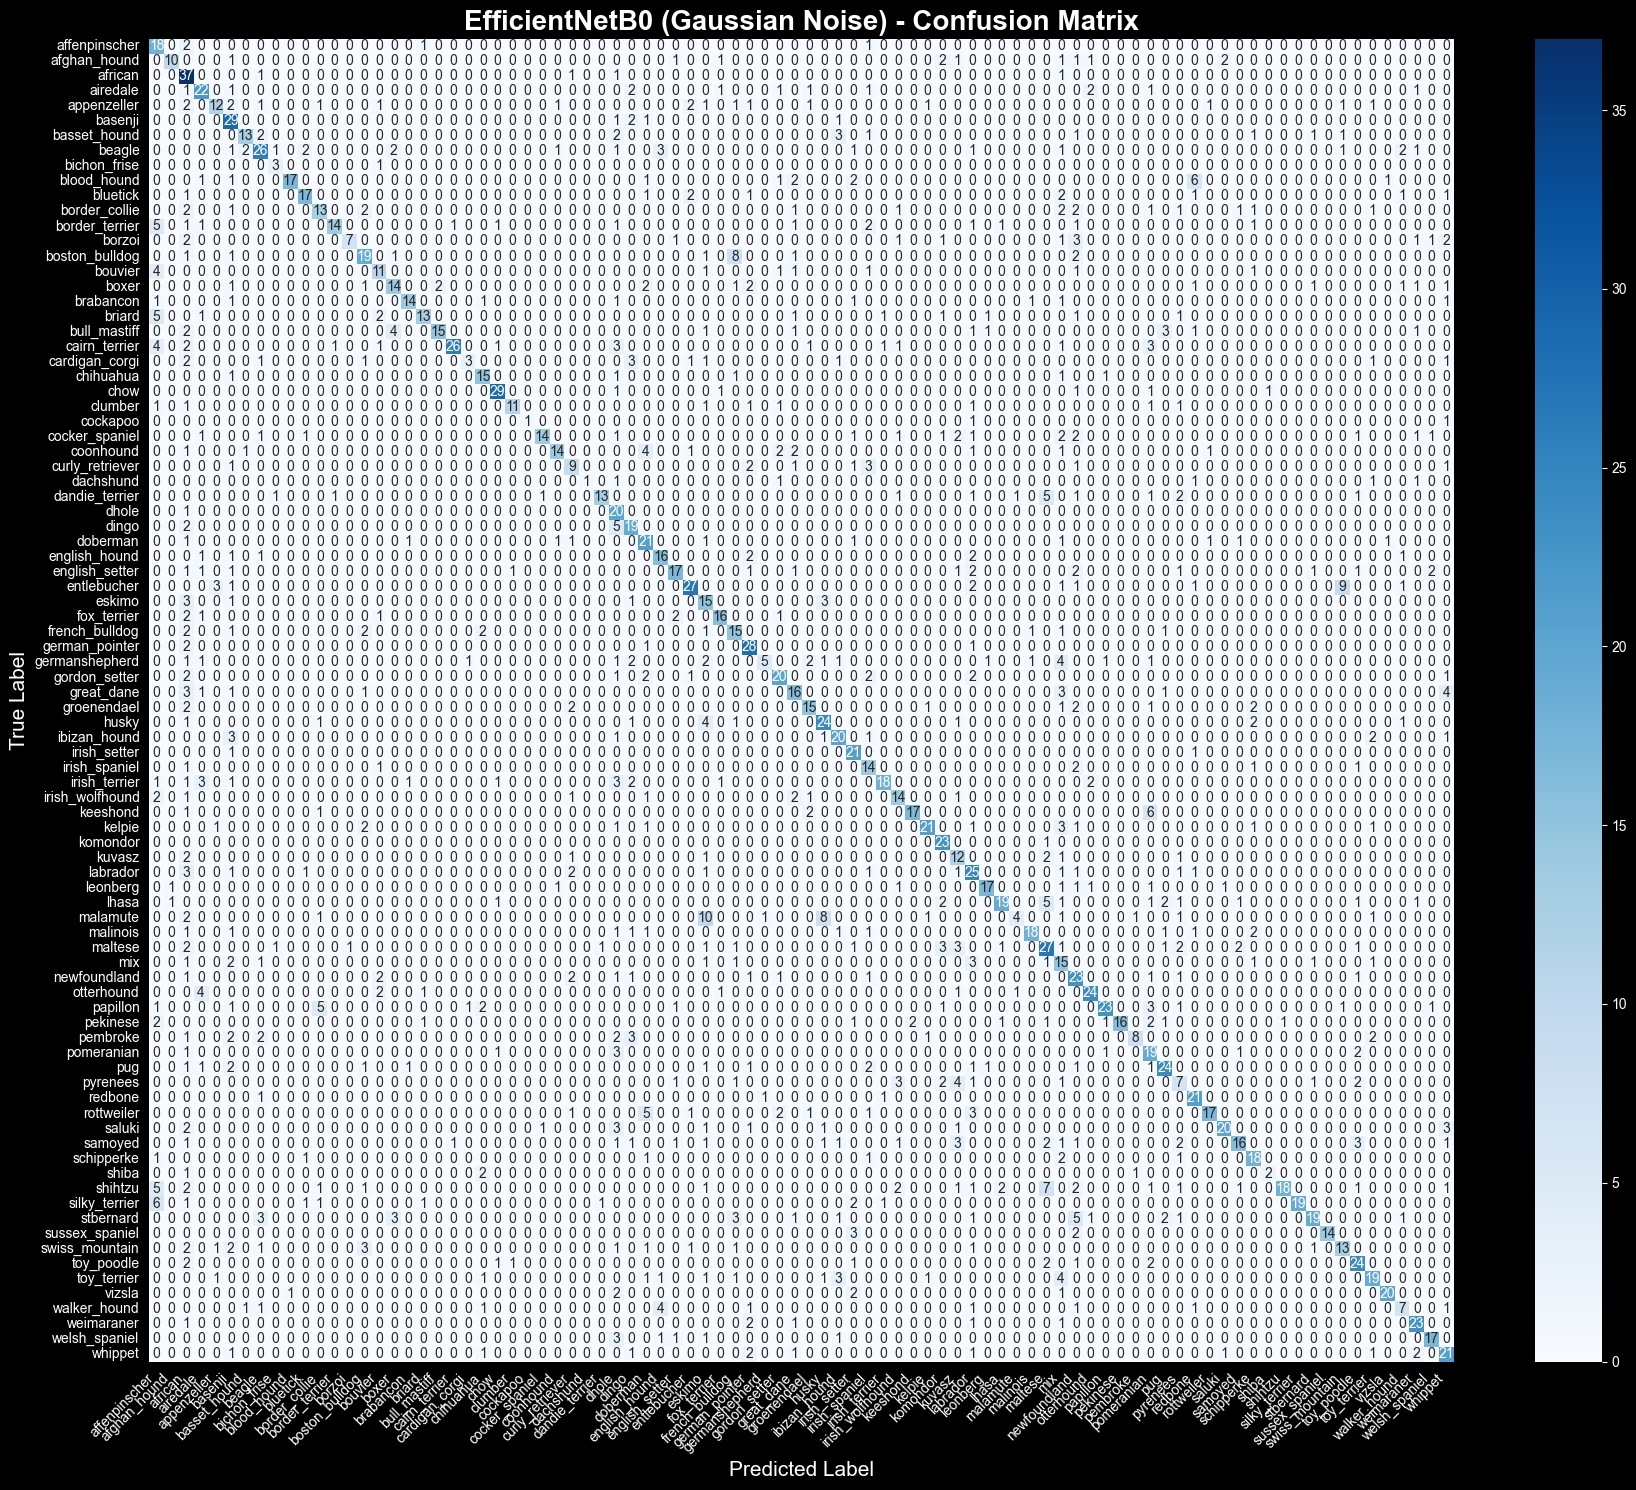

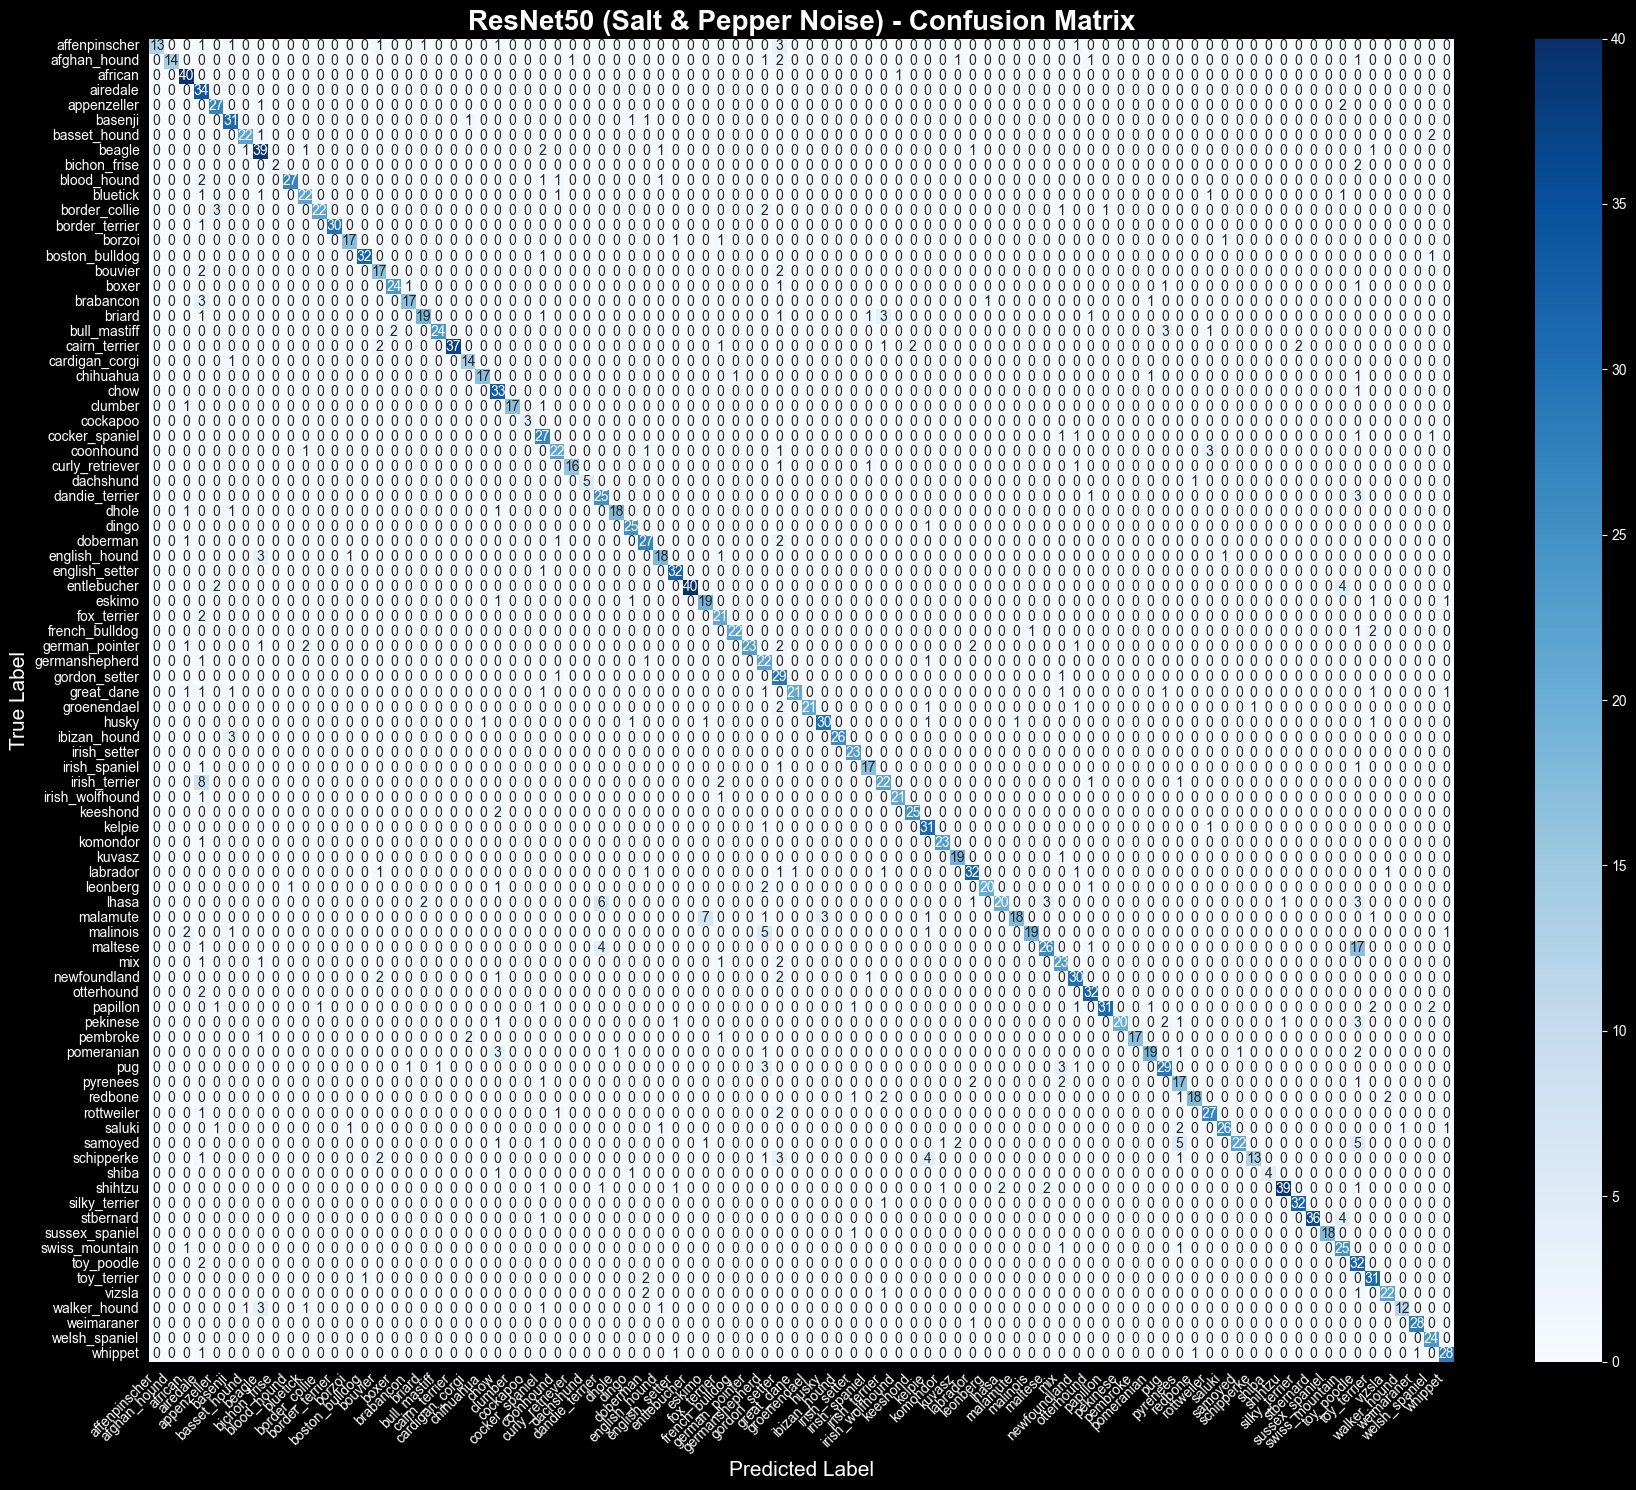

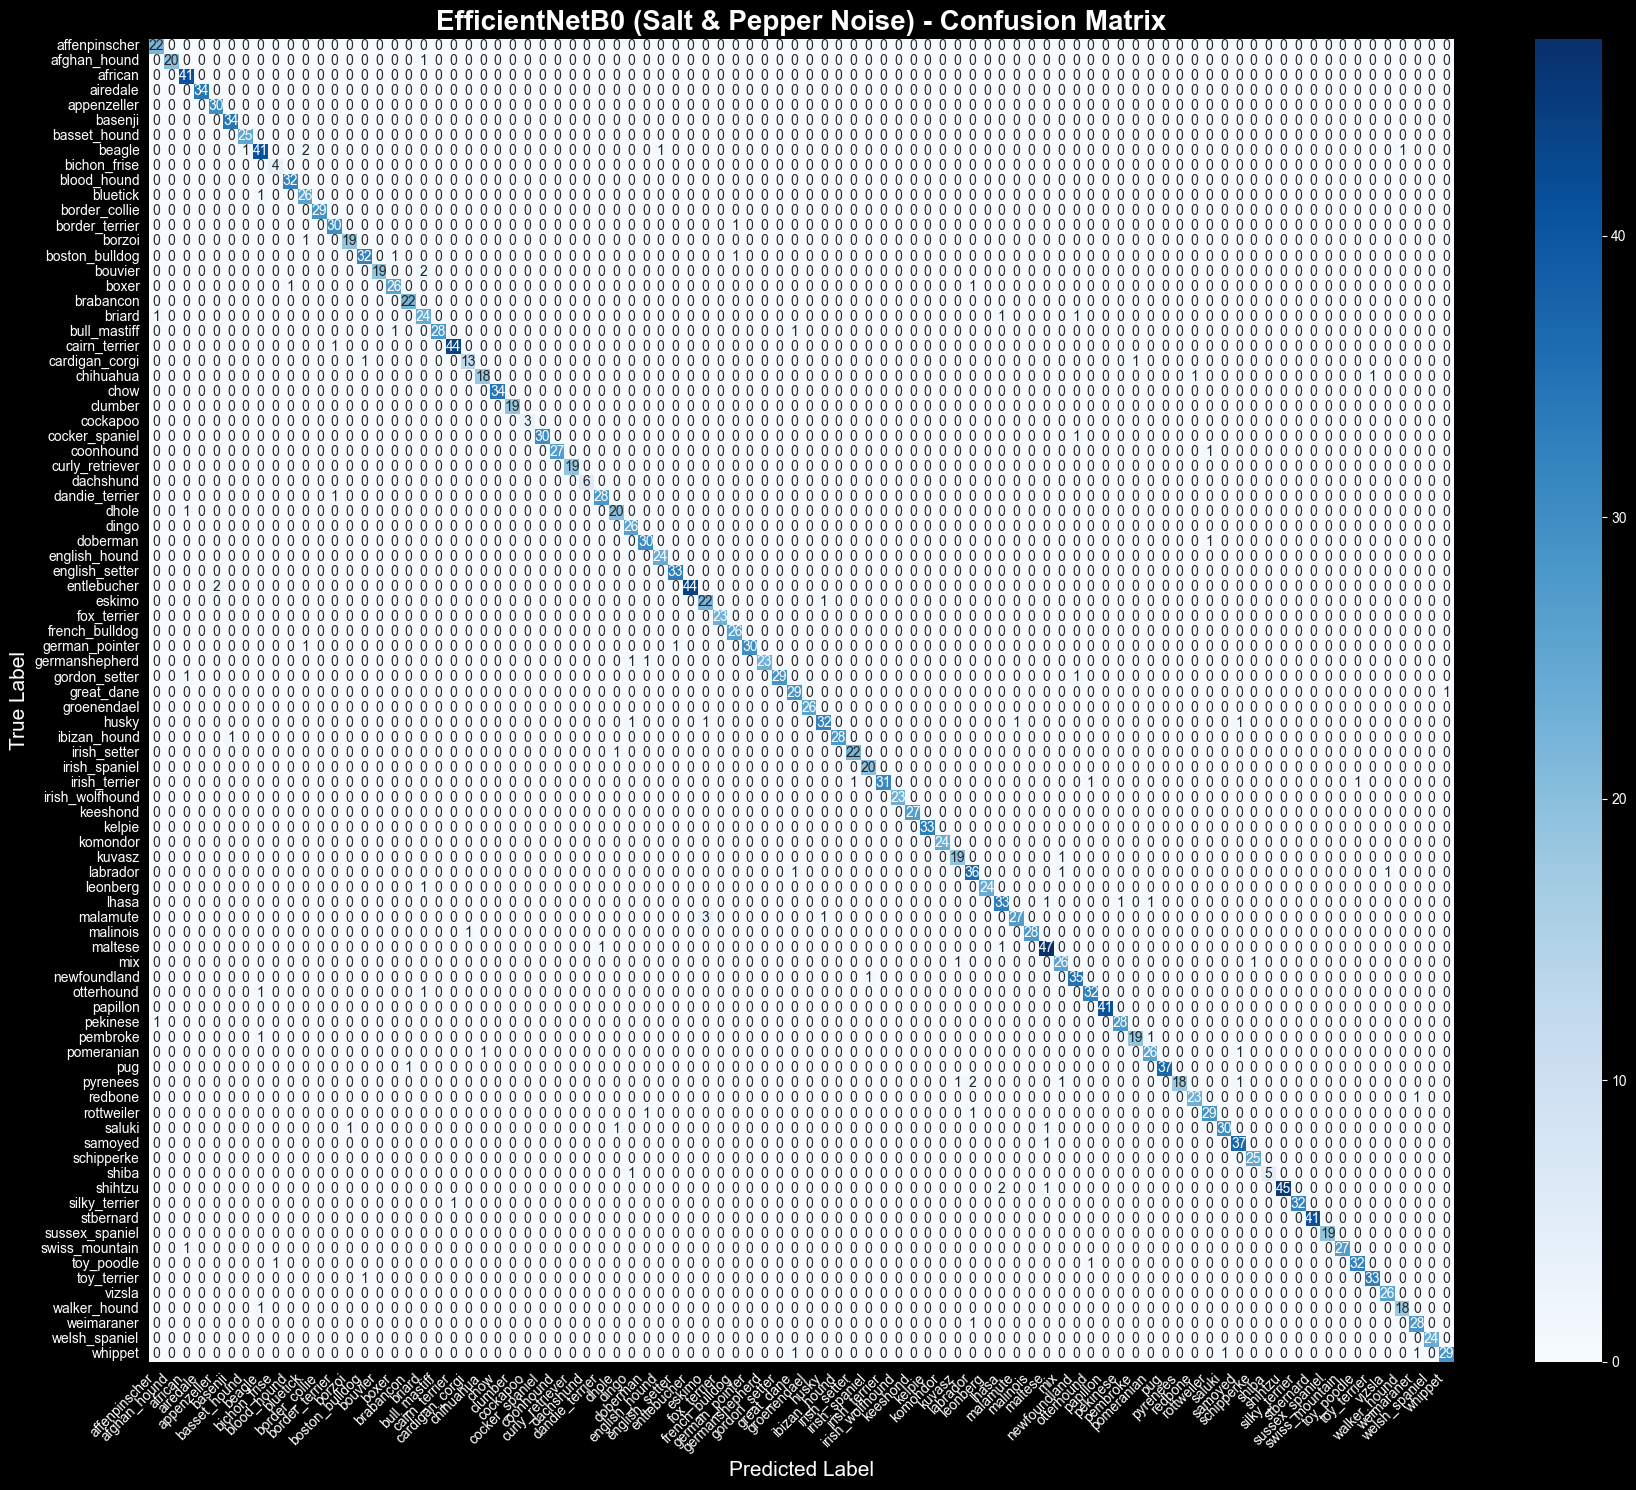

In [15]:
# ══════════════════════════════════════════════════════════════════════
#  Evaluate both models on Gaussian-noisy & Salt-and-Pepper-noisy data


# ---------- Gaussian Noise ----------
print("=" * 70)
print("EVALUATION ON GAUSSIAN NOISY VALIDATION SET")
print("=" * 70)

print("Evaluating ResNet50 on Gaussian noise...")
resnet_gaussian_results = evaluate_model_pytorch(resnet_model, gaussian_val_loader, device, k=3)

print("Evaluating EfficientNetB0 on Gaussian noise...")
efficientnet_gaussian_results = evaluate_model_pytorch(efficientnet_model, gaussian_val_loader, device, k=3)

# ---------- Salt & Pepper Noise ----------
print("\n" + "=" * 70)
print("EVALUATION ON SALT & PEPPER NOISY VALIDATION SET")
print("=" * 70)

print("Evaluating ResNet50 on Salt & Pepper noise...")
resnet_sp_results = evaluate_model_pytorch(resnet_model, sp_val_loader, device, k=3)

print("Evaluating EfficientNetB0 on Salt & Pepper noise...")
efficientnet_sp_results = evaluate_model_pytorch(efficientnet_model, sp_val_loader, device, k=3)

# ══════════════════════════════════════════════════════════════════════
#  Comparison Table: Clean vs Gaussian vs Salt & Pepper
# ══════════════════════════════════════════════════════════════════════
noisy_results_df = pd.DataFrame({
    'Model': [
        'ResNet50 (Clean)',       'EfficientNetB0 (Clean)',
        'ResNet50 (Gaussian)',    'EfficientNetB0 (Gaussian)',
        'ResNet50 (S&P)',         'EfficientNetB0 (S&P)',
    ],
    'Validation Loss': [
        resnet_results['loss'],              efficientnet_results['loss'],
        resnet_gaussian_results['loss'],     efficientnet_gaussian_results['loss'],
        resnet_sp_results['loss'],           efficientnet_sp_results['loss'],
    ],
    'Accuracy (%)': [
        resnet_results['accuracy'],              efficientnet_results['accuracy'],
        resnet_gaussian_results['accuracy'],     efficientnet_gaussian_results['accuracy'],
        resnet_sp_results['accuracy'],           efficientnet_sp_results['accuracy'],
    ],
    'Top-3 Accuracy (%)': [
        resnet_results['top_k_accuracy'],              efficientnet_results['top_k_accuracy'],
        resnet_gaussian_results['top_k_accuracy'],     efficientnet_gaussian_results['top_k_accuracy'],
        resnet_sp_results['top_k_accuracy'],           efficientnet_sp_results['top_k_accuracy'],
    ],
})

print("\n" + "=" * 70)
print("CLEAN vs NOISY PERFORMANCE COMPARISON")
print("=" * 70)
display(noisy_results_df.style.format({
    'Validation Loss': '{:.4f}',
    'Accuracy (%)': '{:.2f}',
    'Top-3 Accuracy (%)': '{:.2f}',
}).hide(axis='index'))

# ══════════════════════════════════════════════════════════════════════
#  Classification Reports
# ══════════════════════════════════════════════════════════════════════
class_names = get_class_names_from_loader(val_loader)

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT — Gaussian Noise")
print("=" * 70)
print("ResNet50 (Gaussian)")
print(classification_report(
    resnet_gaussian_results['labels'],
    resnet_gaussian_results['predictions'],
    target_names=class_names, digits=3, zero_division=0,
))
print("EfficientNetB0 (Gaussian)")
print(classification_report(
    efficientnet_gaussian_results['labels'],
    efficientnet_gaussian_results['predictions'],
    target_names=class_names, digits=3, zero_division=0,
))

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT — Salt & Pepper Noise")
print("=" * 70)
print("ResNet50 (S&P)")
print(classification_report(
    resnet_sp_results['labels'],
    resnet_sp_results['predictions'],
    target_names=class_names, digits=3, zero_division=0,
))
print("EfficientNetB0 (S&P)")
print(classification_report(
    efficientnet_sp_results['labels'],
    efficientnet_sp_results['predictions'],
    target_names=class_names, digits=3, zero_division=0,
))

# ══════════════════════════════════════════════════════════════════════
#  Confusion Matrices — Noisy Data
# ══════════════════════════════════════════════════════════════════════
plot_confusion_matrix(
    resnet_gaussian_results['labels'],
    resnet_gaussian_results['predictions'],
    'ResNet50 (Gaussian Noise)', class_names,
)
plot_confusion_matrix(
    efficientnet_gaussian_results['labels'],
    efficientnet_gaussian_results['predictions'],
    'EfficientNetB0 (Gaussian Noise)', class_names,
)
plot_confusion_matrix(
    resnet_sp_results['labels'],
    resnet_sp_results['predictions'],
    'ResNet50 (Salt & Pepper Noise)', class_names,
)
plot_confusion_matrix(
    efficientnet_sp_results['labels'],
    efficientnet_sp_results['predictions'],
    'EfficientNetB0 (Salt & Pepper Noise)', class_names,
)
